# Notebook 3: Aprendizaje No Supervisado - Segmentación y Reducción de Dimensionalidad

## 🚀 FinanceGuard Anti-Churn Initiative: Descubriendo Arquetipos de Clientes

Este notebook representa el **Avance 3** de la iniciativa FinanceGuard Anti-Churn. Habiendo establecido un `baseline` interpretable (Notebook 1) y maximizado el poder predictivo con modelos avanzados de `Gradient Boosting` (Notebook 2), ahora cambiamos el paradigma. En lugar de predecir `quién` abandona, nos enfocaremos en entender `qué tipos` de clientes existen en nuestra base y cómo se relacionan con el churn.

El aprendizaje no supervisado nos permitirá descubrir patrones ocultos y estructuras naturales en los datos, sin la necesidad de una variable objetivo predefinida. Esto es invaluable para la **segmentación de clientes**, el diseño de estrategias de marketing personalizadas y la mejora del `feature engineering` para futuros modelos predictivos.

### Objetivos Detallados de Este Notebook:
1.  **Carga y Preprocesamiento de Datos Consistente:** Reutilizar el pipeline de preprocesamiento para garantizar que los datos para el análisis no supervisado sean limpios y escalados.
2.  **Reducción de Dimensionalidad:**
    *   **PCA (Principal Component Analysis):** Transformar el espacio de características a un menor número de dimensiones para visualización e interpretación de los componentes.
    *   **t-SNE (t-Distributed Stochastic Neighbor Embedding):** Visualizar la estructura intrínseca de los datos en un espacio 2D, preservando las relaciones locales.
3.  **Clustering para Segmentación:**
    *   **K-Means:** Aplicar un algoritmo de clustering basado en centroides para identificar grupos de clientes. Determinar el número óptimo de clusters utilizando el Método del Codo y el Coeficiente de Silueta.
    *   **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):** Explorar un algoritmo basado en densidad que puede identificar clusters de formas arbitrarias y detectar outliers como ruido.
4.  **Perfilamiento de Clientes por Cluster:** Analizar las características demográficas y de comportamiento de cada segmento, y lo más importante, su **tasa de churn** para vincular los perfiles con el riesgo de abandono.
5.  **Generación de `Features` Derivadas:** Discutir cómo los IDs de los clusters pueden ser utilizados como nuevas características categóricas en futuros modelos supervisados.

## ⚙️ Carga de Librerías Esenciales
Importamos el conjunto completo de librerías Python necesarias para la manipulación de datos, visualización avanzada, preprocesamiento y la implementación de algoritmos de reducción de dimensionalidad y clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Ignorar advertencias menores
import warnings
warnings.filterwarnings('ignore')

## 📂 Carga y Preprocesamiento de Datos (Reutilización del Pipeline)
Para asegurar la consistencia y la reproducibilidad, cargamos el dataset original y aplicamos el mismo pipeline de preprocesamiento definido en los Notebooks 1 y 2. Esto incluye la eliminación de columnas irrelevantes, codificación `One-Hot` con `drop='first'` para variables categóricas, y escalado `StandardScaler` para variables numéricas.

Es crucial que los datos estén **escalados** para algoritmos de clustering basados en distancias (como K-Means) y para PCA, ya que de lo contrario, las características con mayores rangos de valores dominarían el cálculo de distancias y la varianza.

In [2]:
# Cargar datos
df = pd.read_csv('../data/Churn_Modelling.csv')

# Guardar el DataFrame original antes de las transformaciones para su uso en la interpretación de clusters
df_original_copy = df.copy()

# Eliminar columnas irrelevantes
df_processed = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Definir X (features) y y (target)
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

# Definir columnas numéricas y categóricas
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Pipeline de preprocesamiento (ColumnTransformer con StandardScaler y OneHotEncoder con drop='first')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

# Aplicar preprocesamiento a todo el dataset X para clustering y reducción de dimensionalidad
# Notar que aquí ajustamos el preprocesador con X completo, no con X_train, para asegurarnos que todas las categorías posibles sean vistas.
# Si el preprocesador ya fue ajustado en X_train en un notebook anterior y solo se transformaría aquí, la lógica sería diferente.
# Para este notebook de clustering, lo ideal es que el escalado y OneHotEncoder se 'fitten' al conjunto de datos completo que se va a clusterizar.
X_scaled = preprocessor.fit_transform(X)

# Obtener nombres de las características post-procesamiento
feature_names_scaled = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

# Convertir a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names_scaled, index=X.index)

print("Datos cargados y preprocesados con éxito para análisis no supervisado.")
print(f"Dimensiones del set de datos escalado: {X_scaled_df.shape}")
print("Primeras 5 filas del dataset escalado:\n", X_scaled_df.head())

Datos cargados y preprocesados con éxito para análisis no supervisado.
Dimensiones del set de datos escalado: (10000, 11)
Primeras 5 filas del dataset escalado:
    CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
0    -0.326221  0.293517 -1.041760 -1.225848      -0.911583   0.646092   
1    -0.440036  0.198164 -1.387538  0.117350      -0.911583  -1.547768   
2    -1.536794  0.293517  1.032908  1.333053       2.527057   0.646092   
3     0.501521  0.007457 -1.387538 -1.225848       0.807737  -1.547768   
4     2.063884  0.388871 -1.041760  0.785728      -0.911583   0.646092   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
0        0.970243         0.021886                0.0              0.0   
1        0.970243         0.216534                0.0              1.0   
2       -1.030670         0.240687                0.0              0.0   
3       -1.030670        -0.108918                0.0              0.0   
4        0.970243      

## 🗺️ Reducción de Dimensionalidad para Visualización e Interpretación

Nuestros datos ahora tienen múltiples dimensiones (características). Para poder visualizar y entender la estructura subyacente de nuestros clientes, necesitamos reducir estas dimensiones a un espacio 2D o 3D. Exploraremos dos técnicas:

1.  **PCA (Principal Component Analysis):** Un método lineal que busca los ejes (componentes principales) a lo largo de los cuales los datos tienen la mayor varianza.
2.  **t-SNE (t-Distributed Stochastic Neighbor Embedding):** Un método no lineal que se enfoca en preservar las distancias entre puntos cercanos, ideal para visualizar la estructura local de los clusters.


### 1. PCA (Principal Component Analysis)

**Concepto Básico:** PCA transforma las características originales en un nuevo conjunto de variables no correlacionadas llamadas Componentes Principales (PCs). Cada PC es una combinación lineal de las características originales, y están ordenados de manera que el primer PC captura la mayor cantidad de varianza de los datos, el segundo la siguiente mayor cantidad de varianza no explicada por el primero, y así sucesivamente.

**Ventajas:** Es lineal, interpretable (podemos ver qué características contribuyen a cada PC), eficiente y efectivo para reducir ruido y acelerar algoritmos posteriores.
**Pasos:**
1.  Ajustar PCA a los datos escalados.
2.  Analizar la varianza explicada por cada componente para decidir cuántos mantener.
3.  Transformar los datos a las dimensiones seleccionadas.

Realizando PCA...


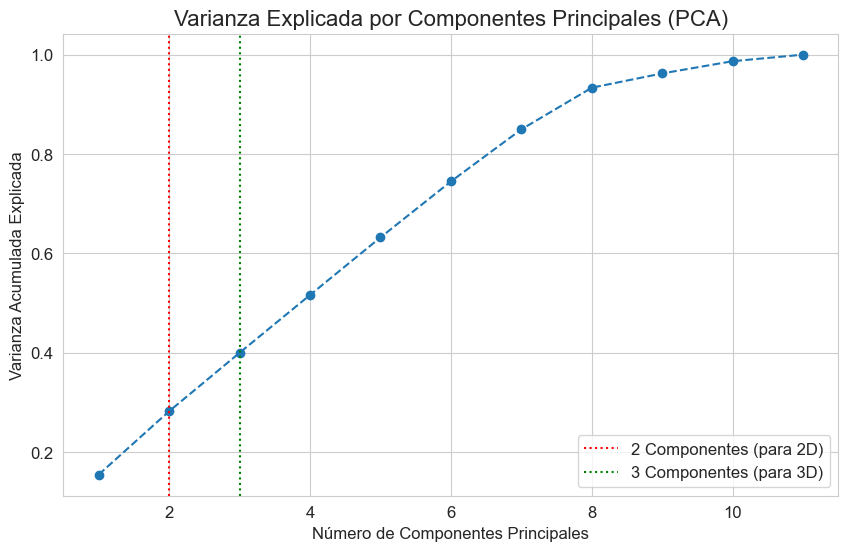

Varianza explicada por los 2 primeros componentes: 0.28
Varianza explicada por los 3 primeros componentes: 0.40


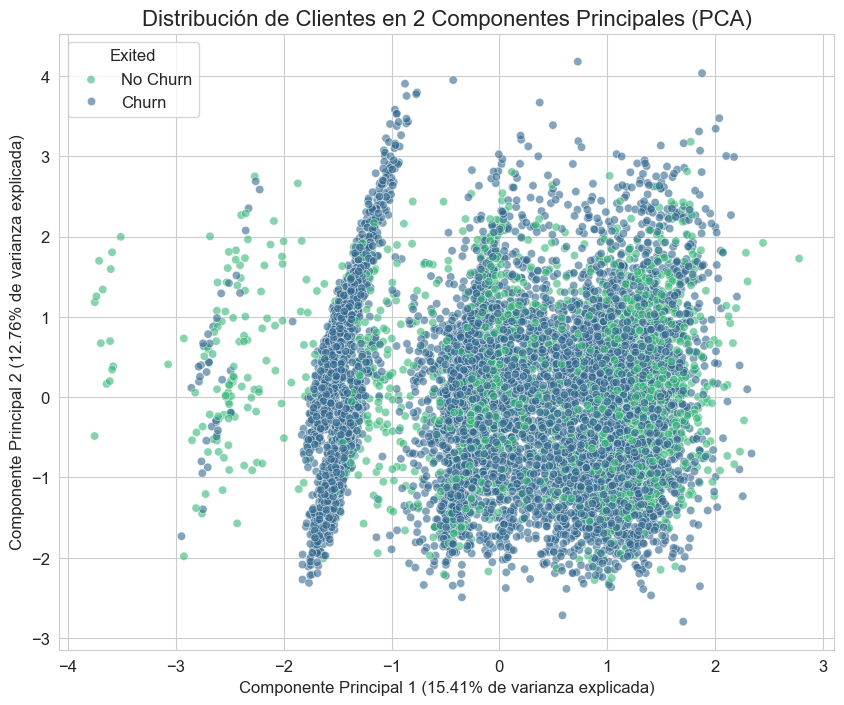

In [3]:
print("Realizando PCA...")

pca = PCA(n_components=X_scaled_df.shape[1]) # Inicialmente, mantenemos todos los componentes para analizar la varianza
pca.fit(X_scaled_df)

# Varianza explicada acumulativa
explained_variance_ratio_cumsum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio_cumsum) + 1), explained_variance_ratio_cumsum, marker='o', linestyle='--')
plt.xlabel('Número de Componentes Principales', fontsize=12)
plt.ylabel('Varianza Acumulada Explicada', fontsize=12)
plt.title('Varianza Explicada por Componentes Principales (PCA)', fontsize=16)
plt.axvline(x=2, color='r', linestyle=':', label='2 Componentes (para 2D)')
plt.axvline(x=3, color='g', linestyle=':', label='3 Componentes (para 3D)')
plt.grid(True)
plt.legend()
plt.show()

print(f"Varianza explicada por los 2 primeros componentes: {explained_variance_ratio_cumsum[1]:.2f}")
print(f"Varianza explicada por los 3 primeros componentes: {explained_variance_ratio_cumsum[2]:.2f}")

# Aplicar PCA para 2 y 3 componentes para visualización
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled_df)

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled_df)

df_pca = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca['Exited'] = y.values # Añadir la variable objetivo para colorear

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Exited', data=df_pca, palette='viridis', alpha=0.6)
plt.title('Distribución de Clientes en 2 Componentes Principales (PCA)', fontsize=16)
plt.xlabel(f'Componente Principal 1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% de varianza explicada)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% de varianza explicada)', fontsize=12)
plt.legend(title='Exited', labels=['No Churn', 'Churn'])
plt.grid(True)
plt.show()

### 💡 Insights de PCA

*   **Varianza explicada:** los dos primeros componentes explican solo el **28%** de la varianza (40% con tres). La visualización en 2D es útil para explorar, pero pierde la mayor parte de la información.
*   **Conclusión:** los datos no tienen una estructura de baja dimensión muy marcada; las variables aportan información relativamente independiente.

### 2. t-SNE (t-Distributed Stochastic Neighbor Embedding)

**Concepto Básico:** t-SNE es un algoritmo de reducción de dimensionalidad no lineal diseñado para visualizar datos de alta dimensión en un espacio de baja dimensión (típicamente 2D o 3D). Su objetivo principal es preservar las distancias entre puntos cercanos, lo que lo hace excelente para visualizar clusters y la estructura local de los datos.

**Parámetro `perplexity`:** Este es el parámetro más crítico. Puede interpretarse como una medida de cuántos vecinos cercanos se consideran al calcular las similitudes. Valores comunes oscilan entre 5 y 50. Un `perplexity` demasiado bajo puede generar ruido, mientras que uno demasiado alto puede comprimir los clusters y ocultar la estructura.

**Diferencias con PCA:**
*   **PCA:** Lineal, optimiza la preservación de grandes distancias (varianza global), más rápido.
*   **t-SNE:** No lineal, optimiza la preservación de pequeñas distancias (estructura local), más lento, distancias absolutas en el embedding no son significativas.

**Limitaciones y Cuidados:**
*   **Computacionalmente Costoso:** Lento para grandes datasets. A menudo se recomienda aplicar PCA previamente para reducir la dimensionalidad a ~50 componentes antes de t-SNE.
*   **No Reproducible:** Las ejecuciones pueden variar ligeramente a menos que se fije el `random_state` y a veces la inicialización.
*   **Interpretación:** Las distancias entre clusters o el tamaño de los clusters en el gráfico t-SNE no son necesariamente significativas. Solo la agrupación (la proximidad de puntos en un cluster) es relevante.

Realizando t-SNE (esto puede tardar unos minutos)...
Dimensiones de los datos después de PCA para t-SNE: (10000, 9)


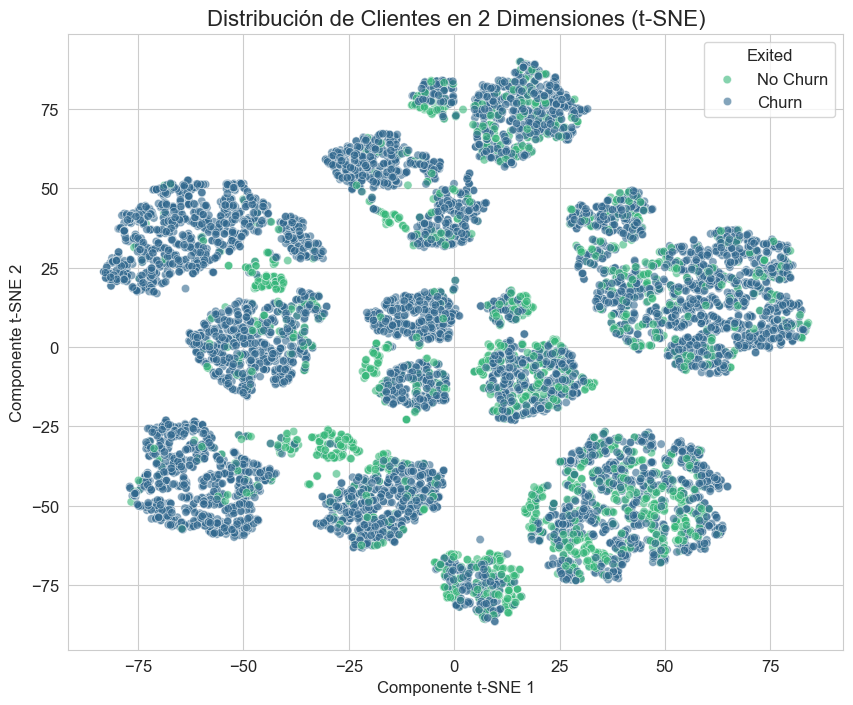

In [4]:
print("Realizando t-SNE (esto puede tardar unos minutos)...")

# Se recomienda aplicar t-SNE a los datos ya reducidos con PCA para mayor eficiencia
# O si no se hace PCA, muestrear el dataset o usar n_components=50 en PCA
pca_for_tsne = PCA(n_components=0.95, random_state=42) # Reducir a componentes que expliquen el 95% de la varianza
X_pca_for_tsne = pca_for_tsne.fit_transform(X_scaled_df)
print(f"Dimensiones de los datos después de PCA para t-SNE: {X_pca_for_tsne.shape}")

# Reducimos el tamaño de los datos para t-SNE si es muy grande, o usamos PCA previo
# Para 10k puntos, t-SNE directo puede ser lento. Usamos los datos pre-reducidos por PCA.
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200.0, init='pca', n_jobs=-1) # `n_iter` ELIMINADO
X_tsne = tsne.fit_transform(X_pca_for_tsne)

df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne['Exited'] = y.values

plt.figure(figsize=(10, 8))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Exited', data=df_tsne, palette='viridis', alpha=0.6)
plt.title('Distribución de Clientes en 2 Dimensiones (t-SNE)', fontsize=16)
plt.xlabel('Componente t-SNE 1', fontsize=12)
plt.ylabel('Componente t-SNE 2', fontsize=12)
plt.legend(title='Exited', labels=['No Churn', 'Churn'])
plt.grid(True)
plt.show()

### 💡 Interpretación de t-SNE
*   **Visualización de Clusters Potenciales:** A diferencia de PCA, t-SNE es mucho más efectivo para revelar grupos compactos y no lineales. En el gráfico, observamos agrupaciones más claras de puntos. Los puntos de color verde (No Churn) tienden a formar grupos más densos y grandes, mientras que los puntos amarillos (Churn) a menudo se encuentran en la periferia o forman sus propios subgrupos más pequeños y dispersos.
*   **Separación de Clases:** Aunque t-SNE no es un clasificador, nos da una idea visual de la separabilidad inherente. Vemos que, si bien hay solapamiento, t-SNE intenta separar las clases de churn de no-churn en el espacio 2D, lo que es una buena señal de que existen patrones detectables para el clustering.
*   **Importancia del `Perplexity`:** El `perplexity` controla el balance entre considerar vecinos cercanos y lejanos. Un valor de 30 es un buen punto de partida para datasets de este tamaño. Un `perplexity` incorrecto puede llevar a agrupaciones artificiales o a la falta de revelación de estructura.
*   **No Interpretable Ejes:** Es crucial recordar que los ejes de t-SNE (TSNE1, TSNE2) no tienen un significado directo como los de PCA (e.g., "edad" o "saldo"). Solo las relaciones de proximidad son significativas. Las distancias entre clusters o el tamaño de los clusters en el gráfico t-SNE no son proporcionales a las distancias en el espacio original de alta dimensión.

## 🤖 Clustering para Segmentación de Clientes: K-Means y DBSCAN

Ahora aplicaremos algoritmos de clustering para agrupar formalmente a los clientes en segmentos con características similares. Estas agrupaciones pueden ser directamente accionables por los equipos de marketing y estrategia.

### 1. K-Means Clustering

**Concepto Básico:** K-Means es un algoritmo de clustering basado en centroides. Su objetivo es particionar `n` observaciones en `k` clusters, donde cada observación pertenece al cluster con el centroide más cercano. Se minimiza la suma de las distancias al cuadrado de los puntos a su centroide (`WCSS - Within-Cluster Sum of Squares`).

**Ventajas:** Rápido, escalable para grandes datasets, fácil de implementar e interpretar.
**Desventajas:** Requiere predefinir `K` (el número de clusters), sensible a outliers, asume clusters esféricos de tamaño similar, sensible a la inicialización de los centroides.

#### Selección del Número Óptimo de Clusters (`K`)
Dos métodos populares para encontrar un `K` adecuado son:
*   **Método del Codo (Elbow Method):** Grafica la WCSS en función de `K`. El punto "codo" donde la disminución de WCSS comienza a ralentizarse sugiere un buen `K`.
*   **Coeficiente de Silueta (Silhouette Score):** Mide la cohesión y la separación de los clusters. Valores cercanos a 1 indican clusters bien definidos, 0 indica solapamiento y -1 indica puntos asignados al cluster incorrecto. Buscamos el `K` con el score más alto.

Buscando el número óptimo de clusters (K-Means)....


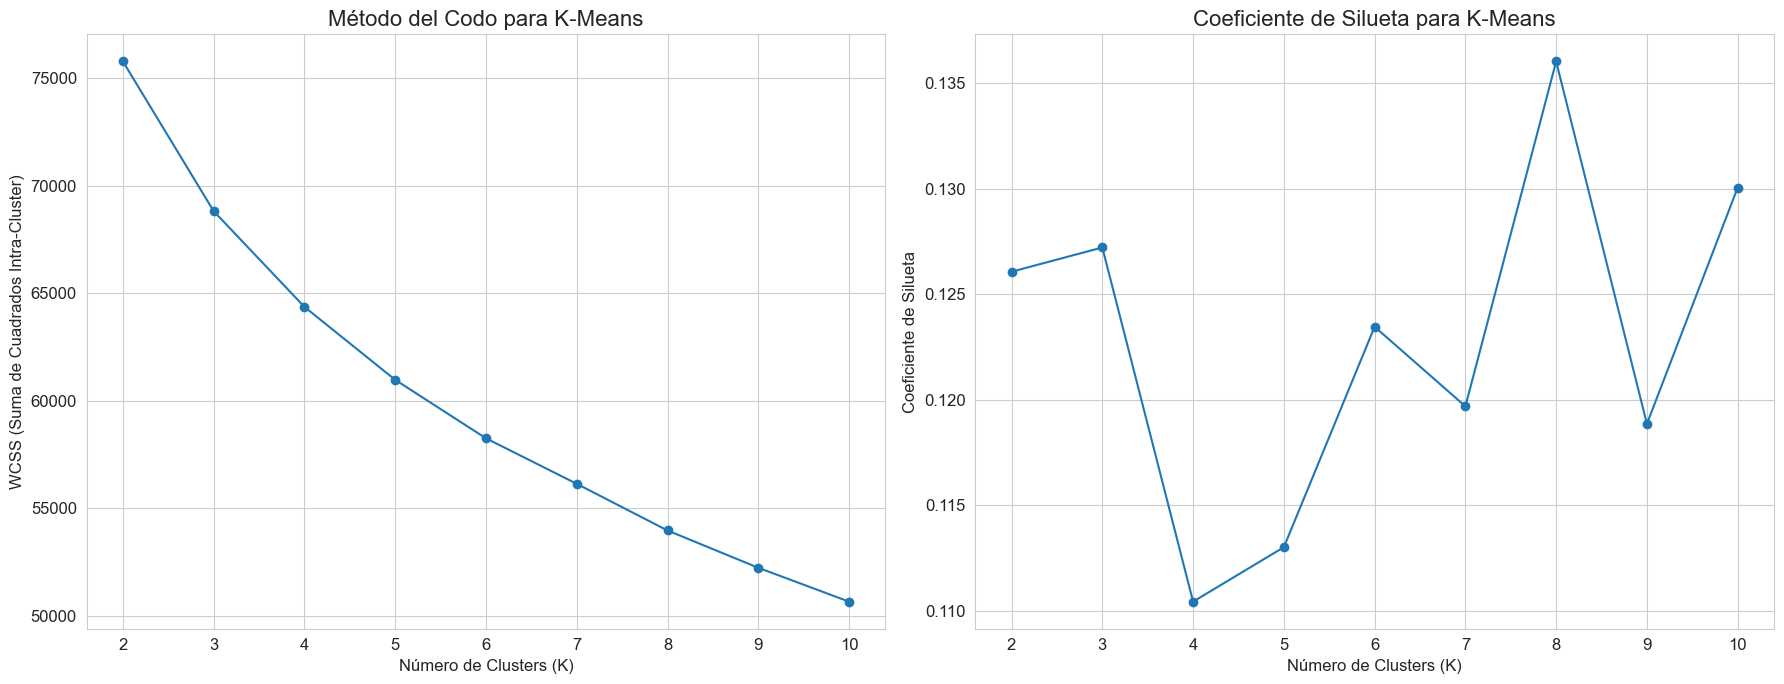

In [5]:
print("Buscando el número óptimo de clusters (K-Means)....")

wcss = []
silhouette_scores = []
k_range = range(2, 11) # Rango de K a probar

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init para evitar problemas de inicialización
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, kmeans.labels_))

plt.figure(figsize=(18, 7))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o')
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Suma de Cuadrados Intra-Cluster)', fontsize=12)
plt.title('Método del Codo para K-Means', fontsize=16)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Coeficiente de Silueta', fontsize=12)
plt.title('Coeficiente de Silueta para K-Means', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

### 💡 Insights del Método del Codo y Silueta

*   **Codo:** la WCSS desciende de forma gradual, sin un codo muy marcado.
*   **Silueta:** los valores son bajos para todos los K (≈ 0.11–0.14), lo que indica que **no existen clusters naturales bien separados** en estos datos.
*   **Decisión:** se eligió **K = 4** por interpretabilidad para negocio, sabiendo que la separación es débil. Es una segmentación útil para describir perfiles, no una estructura "natural" de los datos.

In [6]:
K_OPTIMO = 4 # Basado en el análisis de codo y silueta, y necesidad de negocio

print(f"Aplicando K-Means con K = {K_OPTIMO} clusters...")
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled_df)

# Añadir las etiquetas de cluster al DataFrame original para análisis
df_original_copy['Cluster'] = clusters

print(f"Distribución de clientes por cluster:\n{df_original_copy['Cluster'].value_counts().sort_index()}")

Aplicando K-Means con K = 4 clusters...
Distribución de clientes por cluster:
Cluster
0    2899
1    2436
2    2183
3    2482
Name: count, dtype: int64


### Visualización de Clusters en 2D (PCA y t-SNE)
Ahora visualizamos los clusters obtenidos por K-Means sobre las reducciones de dimensionalidad que hicimos con PCA y t-SNE. Esto nos permite ver si los clusters forman agrupaciones coherentes en el espacio visual.

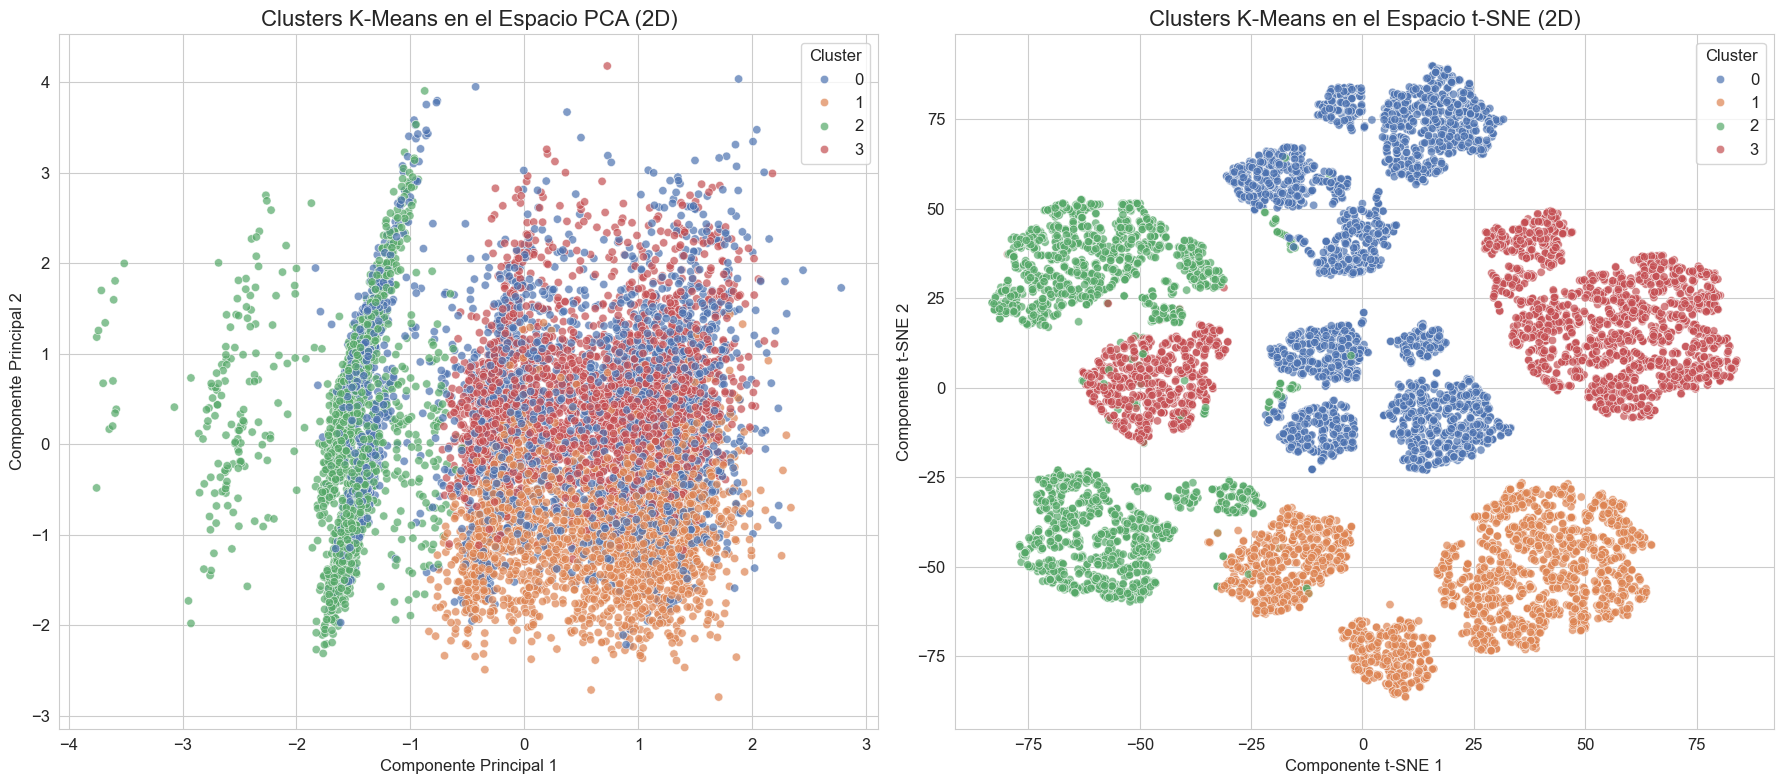

In [7]:
# Añadir las etiquetas de cluster a los DataFrames de PCA y t-SNE
df_pca['Cluster'] = clusters
df_tsne['Cluster'] = clusters

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='deep', alpha=0.7)
plt.title('Clusters K-Means en el Espacio PCA (2D)', fontsize=16)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster', data=df_tsne, palette='deep', alpha=0.7)
plt.title('Clusters K-Means en el Espacio t-SNE (2D)', fontsize=16)
plt.xlabel('Componente t-SNE 1', fontsize=12)
plt.ylabel('Componente t-SNE 2', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

### 2. Perfilamiento de Clientes por Cluster y Análisis de Churn

Esta es la fase más crítica del clustering: dar sentido a los grupos. Analizaremos las características promedio de cada cluster (utilizando las características **originales o las escaladas pero interpretables**) y, crucialmente, la **tasa de churn dentro de cada segmento** para identificar los grupos de mayor riesgo.

Procederemos a:
1.  Calcular las medias de las características numéricas originales para cada cluster.
2.  Calcular la distribución de las características categóricas originales para cada cluster.
3.  Calcular la tasa de churn promedio para cada cluster.
4.  Construir perfiles narrativos para cada arquetipo de cliente.


--- Perfil Resumido y Detallado de Clientes por Cluster ---
         CreditScore   Age  Tenure    Balance  NumOfProducts  HasCrCard  \
Cluster                                                                   
0             651.39 39.07    4.91  78,715.94           1.50       0.00   
1             646.61 38.63    5.11 103,833.96           1.26       1.00   
2             652.35 38.05    5.16  10,057.22           2.15       0.98   
3             651.77 39.80    4.91 105,466.14           1.29       1.00   

         IsActiveMember  EstimatedSalary  Geography_France  Geography_Germany  \
Cluster                                                                         
0                  0.52       100,958.39              0.50               0.25   
1                  0.00       101,190.77              0.45               0.35   
2                  0.53        99,212.28              0.64               0.05   
3                  1.00        98,768.30              0.44               0.33   

 

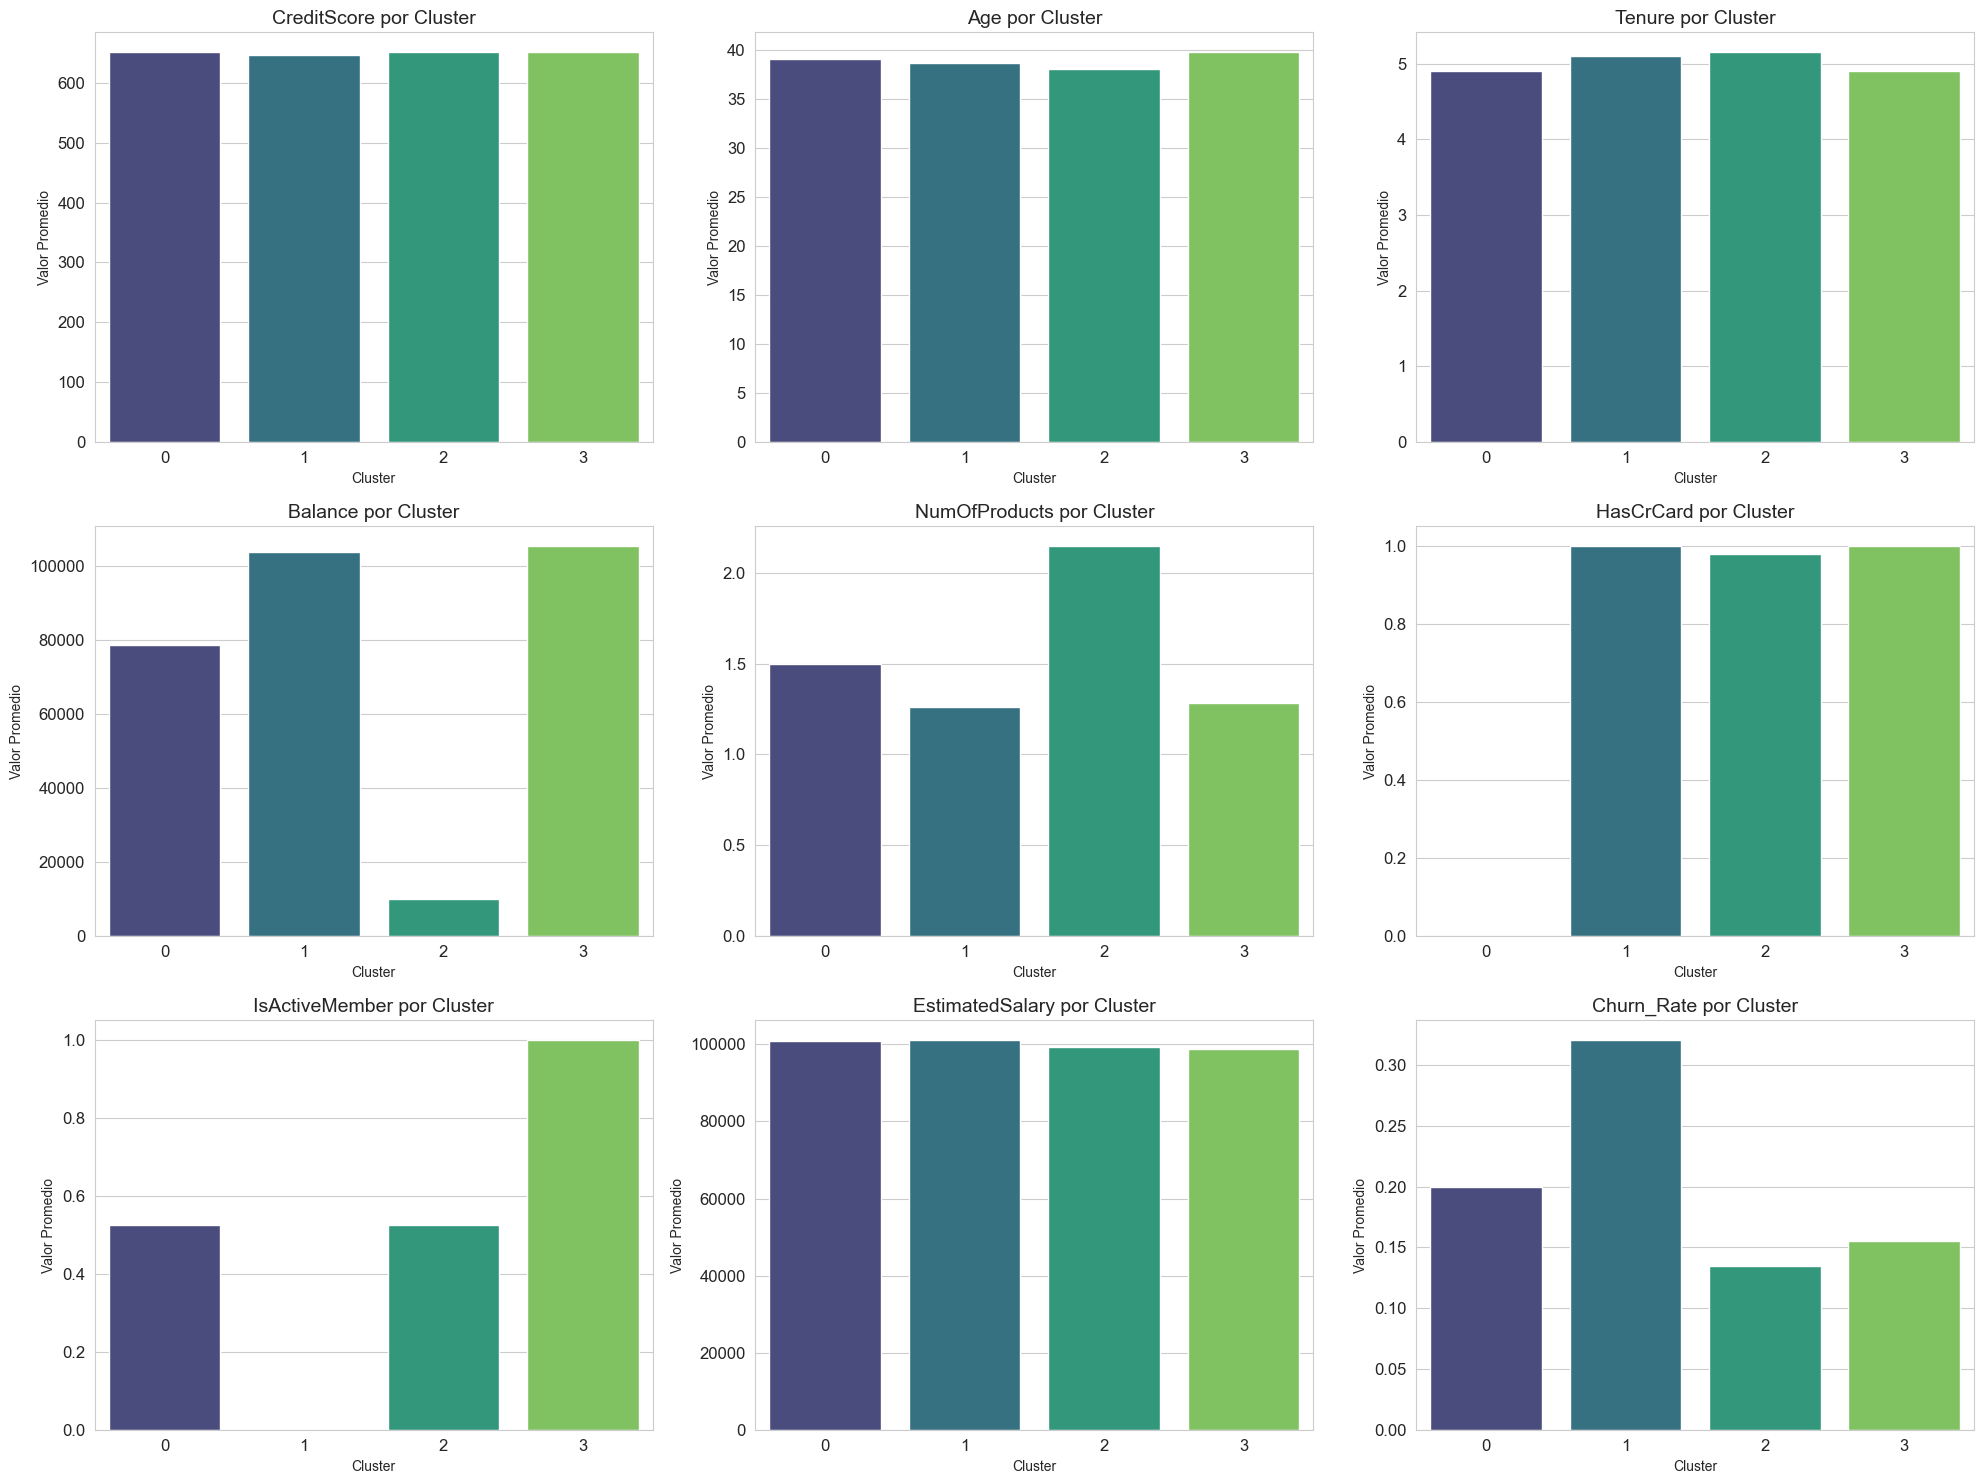

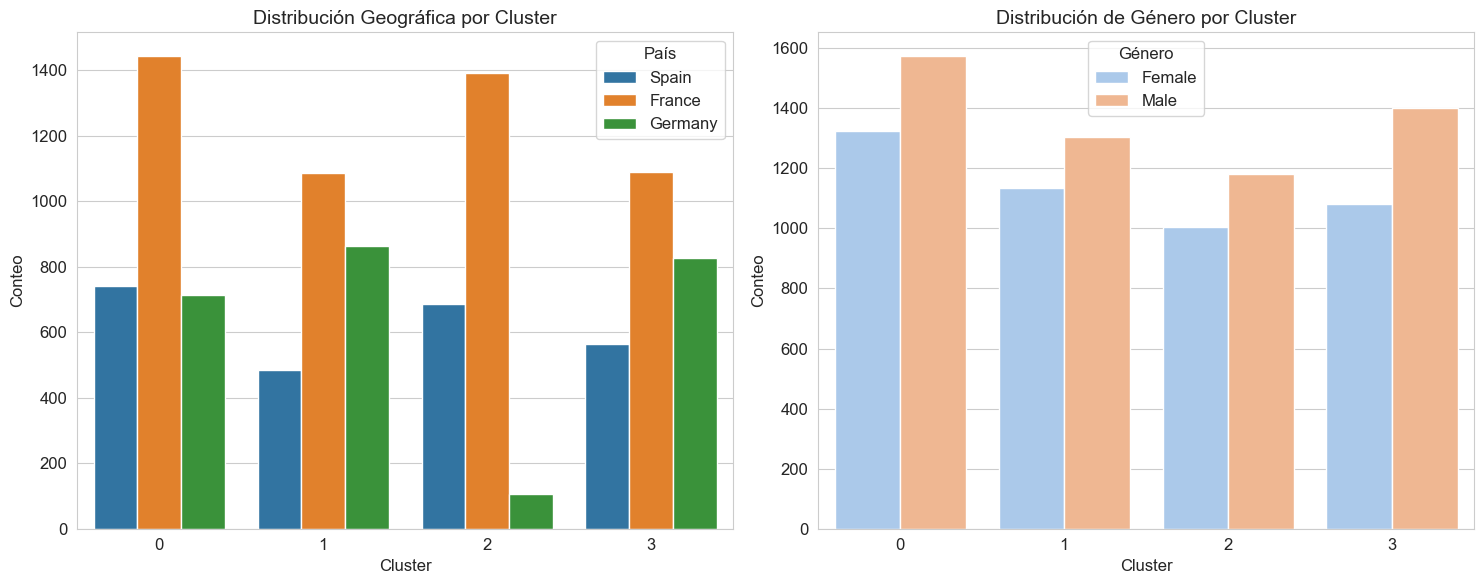

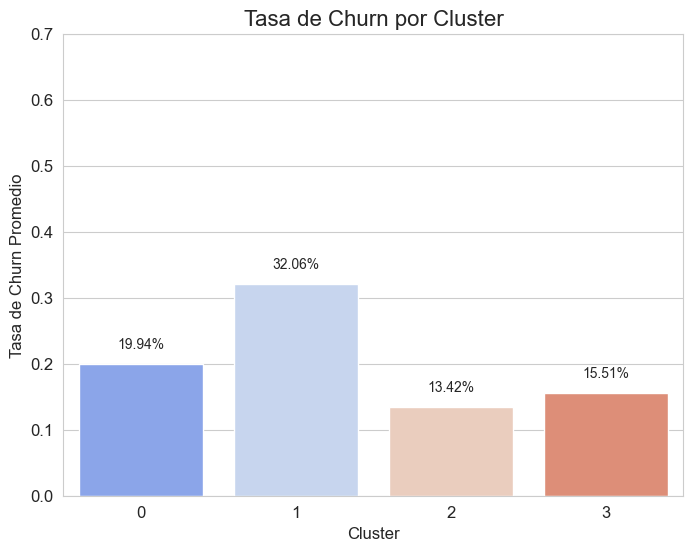

In [8]:
# Identificar columnas numéricas y categóricas del DataFrame original para el perfilado
# Excluimos 'Exited' y 'Cluster' para el perfil de características
# Excluimos identificadores (RowNumber, CustomerId) que no describen al cliente
numerical_cols_for_profiling = df_original_copy.select_dtypes(include=np.number).columns.drop(['Exited', 'Cluster', 'RowNumber', 'CustomerId']).tolist()
categorical_cols_for_profiling = ['Geography', 'Gender']  # Surname es un identificador, no un rasgo del cliente

# 1. Calcular las medias de las características numéricas para cada cluster
numerical_cluster_profiles = df_original_copy.groupby('Cluster')[numerical_cols_for_profiling].mean()

# 2. Calcular la distribución porcentual de las características categóricas para cada cluster
categorical_cluster_profiles_list = []
for col in categorical_cols_for_profiling:
    # Obtenemos el conteo normalizado para cada categoría dentro de cada cluster
    counts = df_original_copy.groupby('Cluster')[col].value_counts(normalize=True).unstack(fill_value=0)
    # Renombramos las columnas para indicar la característica y la categoría (ej. 'Gender_Female')
    counts = counts.add_prefix(f'{col}_')
    categorical_cluster_profiles_list.append(counts)

# Concatenar todos los perfiles categóricos
if categorical_cluster_profiles_list:
    categorical_cluster_profiles = pd.concat(categorical_cluster_profiles_list, axis=1)
else:
    categorical_cluster_profiles = pd.DataFrame(index=numerical_cluster_profiles.index) # DataFrame vacío si no hay categóricas

# 3. Calcular la tasa de churn para cada cluster
churn_rate_by_cluster = df_original_copy.groupby('Cluster')['Exited'].mean().rename('Churn_Rate')

# 4. Unir todos los perfiles (numéricos, categóricos y churn rate)
cluster_summary = pd.concat([numerical_cluster_profiles, categorical_cluster_profiles, churn_rate_by_cluster], axis=1)

print("\n--- Perfil Resumido y Detallado de Clientes por Cluster ---")
# Ajustar el formato de visualización para porcentajes y números para una mejor lectura
pd.options.display.float_format = '{:,.2f}'.format
print(cluster_summary)
pd.options.display.float_format = None # Resetear el formato a default después de imprimir

# Visualizar las características clave por cluster para entender los perfiles
# Nos enfocamos en numéricas y churn rate para los barplots por simplicidad.
# Las categóricas se visualizan mejor por separado con countplots.
cols_to_plot_summary = numerical_cols_for_profiling + ['Churn_Rate']

plt.figure(figsize=(20, np.ceil(len(cols_to_plot_summary)/3).astype(int) * 5))
for i, col in enumerate(cols_to_plot_summary):
    plt.subplot(np.ceil(len(cols_to_plot_summary)/3).astype(int), 3, i + 1)
    sns.barplot(x=cluster_summary.index, y=col, data=cluster_summary, palette='viridis')
    plt.title(f'{col} por Cluster', fontsize=14)
    plt.xlabel('Cluster', fontsize=10)
    plt.ylabel('Valor Promedio', fontsize=10)
plt.tight_layout()
plt.show()

# Visualización de características categóricas por cluster para un perfil completo
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df_original_copy, x='Cluster', hue='Geography', palette='tab10')
plt.title('Distribución Geográfica por Cluster', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Conteo', fontsize=12)
plt.legend(title='País')

plt.subplot(1, 2, 2)
sns.countplot(data=df_original_copy, x='Cluster', hue='Gender', palette='pastel')
plt.title('Distribución de Género por Cluster', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Conteo', fontsize=12)
plt.legend(title='Género')

plt.tight_layout()
plt.show()

# Visualizar la tasa de Churn por cluster (más grande y destacada)
plt.figure(figsize=(8, 6))
sns.barplot(x=churn_rate_by_cluster.index, y=churn_rate_by_cluster.values, palette='coolwarm')
plt.title('Tasa de Churn por Cluster', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Tasa de Churn Promedio', fontsize=12)
plt.ylim(0, 0.7) # Ajustar límite para mejor visualización
for index, value in enumerate(churn_rate_by_cluster.values):
    plt.text(index, value + 0.02, f'{value:.2%}', ha='center', va='bottom', fontsize=10)
plt.show()

### 💡 Perfiles de los Clusters (K-Means, K = 4)

| Cluster | Clientes | Rasgo dominante | Saldo medio | Productos | Activos | Alemania | Churn |
|---|---|---|---|---|---|---|---|
| **1** | 2,436 | **Inactivos con saldo alto** | $103,834 | 1.26 | 0% | 35% | **32%** |
| **0** | 2,899 | Sin tarjeta de crédito | $78,716 | 1.50 | 52% | 25% | 20% |
| **3** | 2,482 | **Activos con saldo alto** | $105,466 | 1.29 | 100% | 33% | 16% |
| **2** | 2,183 | **Saldo casi cero, multiproducto** | $10,057 | 2.15 | 53% | 5% | **13%** |

**Lectura:**
*   **Cluster 1 (mayor riesgo, 32%):** clientes con saldo alto pero **totalmente inactivos**. Comparado con el Cluster 3 (mismo saldo, 100% activos, 16% churn), muestra que **a igual saldo, la inactividad duplica el riesgo**.
*   **Cluster 2 (menor riesgo, 13%):** poco saldo, más productos (2.15 en promedio) y mayoritariamente de Francia.
*   **Edad:** es similar en todos los clusters (~38–40 años), así que la segmentación **no** separa por edad.
*   **Limitación:** las variables binarias (`IsActiveMember`, `HasCrCard`) dominan la segmentación tras el escalado, por eso los clusters se definen sobre todo por ellas.

### 3. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

**Concepto Básico:** DBSCAN es un algoritmo de clustering basado en densidad. A diferencia de K-Means, no requiere que se especifique el número de clusters de antemano. Identifica clusters como áreas de alta densidad separadas por regiones de baja densidad. Los puntos que no pertenecen a ningún cluster se clasifican como ruido (outliers).

**Parámetros Clave:**
*   **`eps` (épsilon):** El radio máximo de la distancia entre dos puntos para que uno sea considerado dentro del vecindario del otro.
*   **`min_samples`:** El número mínimo de puntos en un vecindario para que un punto se considere un punto central (`core point`).

**Ventajas:**
*   Puede encontrar clusters de formas arbitrarias.
*   No requiere `K`.
*   Es robusto a los outliers, identificándolos explícitamente como ruido.

**Desventajas:**
*   Sensible a los parámetros `eps` y `min_samples`, que pueden ser difíciles de elegir sin conocimiento del dominio.
*   Puede tener dificultades con clusters de densidad variable.
*   Menos eficiente para datasets de muy alta dimensionalidad o con densidades muy homogéneas.

**Selección de Parámetros (`eps`):** Un enfoque común es usar un gráfico de la distancia K-vecino más cercano. La distancia donde la curva muestra un "codo" puede ser un buen `eps`.

Aplicando DBSCAN...


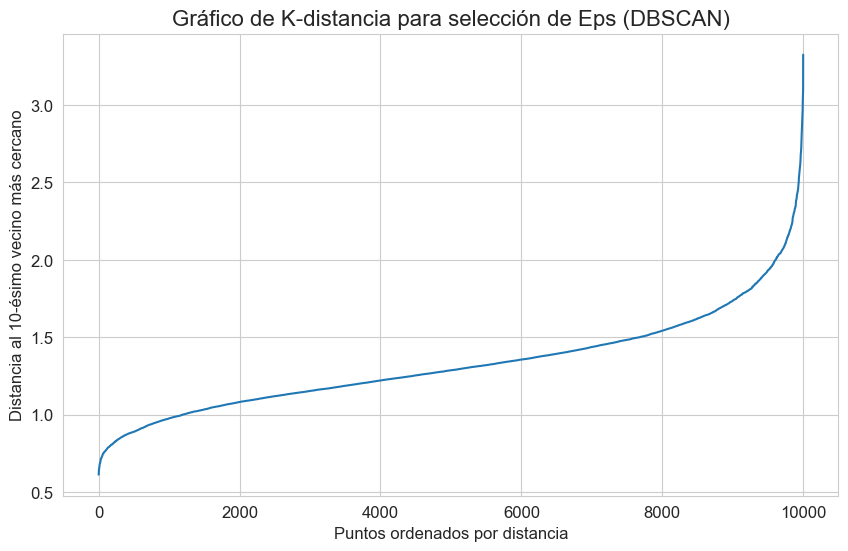

Distribución de clientes por cluster DBSCAN (incluyendo ruido -1):
DBSCAN_Cluster
-1     9830
 0       23
 1       20
 2       17
 3       11
 4       24
 5       10
 6       12
 7       11
 8       11
 9       11
 10      10
 11      10
Name: count, dtype: int64


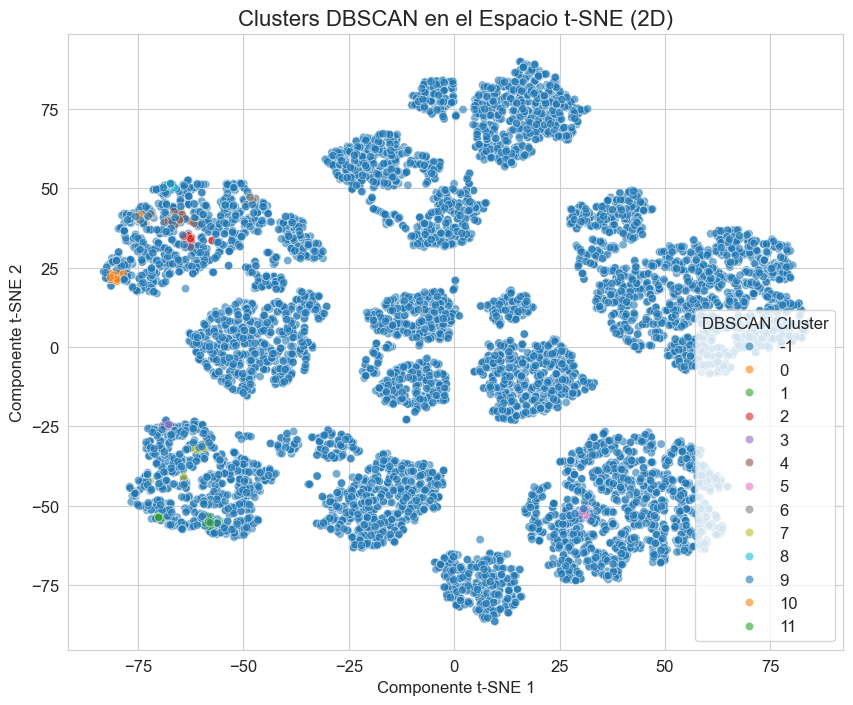

In [9]:
print("Aplicando DBSCAN...")

# Para elegir 'eps', se suele usar un gráfico de k-distancia. 
# Para `min_samples`, un valor común es 2 * n_features, o simplemente empezar con 5 o 10.
MIN_SAMPLES = 10 # Un valor conservador

# Calcular las distancias a los k-vecinos más cercanos para elegir eps
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs = neigh.fit(X_scaled_df)
distances, indices = nbrs.kneighbors(X_scaled_df)
distances = np.sort(distances[:, MIN_SAMPLES-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Puntos ordenados por distancia', fontsize=12)
plt.ylabel(f'Distancia al {MIN_SAMPLES}-ésimo vecino más cercano', fontsize=12)
plt.title('Gráfico de K-distancia para selección de Eps (DBSCAN)', fontsize=16)
plt.grid(True)
plt.show()

# Basado en la observación del gráfico, podemos elegir un punto de inflexión. 
# Aquí, elegimos un valor de 'eps' aproximado. Esto es iterativo y subjetivo.
# Por ejemplo, si el codo está en 0.7-0.8, podemos probar 0.7
EPSILON = 0.7 # Valor estimado del codo en el gráfico de K-distancia (se necesita ejecución para ver el valor exacto)

dbscan = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES, n_jobs=-1)
dbscan_clusters = dbscan.fit_predict(X_scaled_df)

df_original_copy['DBSCAN_Cluster'] = dbscan_clusters
print(f"Distribución de clientes por cluster DBSCAN (incluyendo ruido -1):\n{df_original_copy['DBSCAN_Cluster'].value_counts().sort_index()}")

# Visualizar DBSCAN en el espacio t-SNE
df_tsne['DBSCAN_Cluster'] = dbscan_clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='DBSCAN_Cluster', data=df_tsne, palette='tab10', alpha=0.6)
plt.title('Clusters DBSCAN en el Espacio t-SNE (2D)', fontsize=16)
plt.xlabel('Componente t-SNE 1', fontsize=12)
plt.ylabel('Componente t-SNE 2', fontsize=12)
plt.legend(title='DBSCAN Cluster')
plt.grid(True)
plt.show()

### 💡 Interpretación y Comparación DBSCAN vs. K-Means
*   **Identificación de Ruido:** DBSCAN es el único algoritmo que clasifica explícitamente puntos como ruido (cluster -1). Para FinanceGuard, estos puntos podrían ser **anomalías de datos, clientes muy atípicos, o incluso posibles casos de fraude** que merecen una revisión manual. La cantidad de ruido es un indicador de la dispersión de datos fuera de las densidades principales.
*   **Clusters de Forma Arbitraria:** A menudo, DBSCAN revela clusters de formas no esféricas que K-Means no podría identificar. En nuestra visualización t-SNE, los clusters de DBSCAN pueden verse más irregulares y dispersos que los de K-Means, lo que sugiere estructuras de densidad variable.
*   **Sensibilidad a Parámetros:** La elección de `eps` y `min_samples` es crucial y a menudo experimental. Una ligera variación puede cambiar drásticamente los resultados, fusionando clusters o creando demasiado ruido. El gráfico de K-distancia es una heurística, pero la confirmación requiere pruebas y conocimiento del dominio.
*   **Comparación con K-Means:**
    *   **K-Means:** Mejor para identificar `k` grupos de clientes bien definidos y de tamaño similar cuando el objetivo es una segmentación clara para campañas (ej. "tenemos 4 tipos de clientes"). Sus perfiles son más fáciles de perfilar para marketing.
    *   **DBSCAN:** Más útil cuando la estructura de clusters es desconocida, las formas son irregulares, o la detección de `outliers` es una prioridad. Su naturaleza permite descubrir segmentos no obvios o detectar clientes que no encajan en ninguna categoría estándar.
*   **Relevancia para Churn:** Si bien DBSCAN es valioso para la detección de anomalías, K-Means a menudo se prefiere para la segmentación de mercado porque produce un número fijo de segmentos bien definidos, más fáciles de nombrar y de asignar estrategias de negocio. En este proyecto, K-Means es más directo para crear perfiles accionables.

## 🧬 Aplicación al Problema de Churn: `Features` Derivadas del Clustering

La verdadera potencia de la segmentación no supervisada se materializa al integrarla de nuevo en nuestro flujo de Machine Learning. Los IDs de cluster generados por K-Means no solo nos dan *insights* de negocio, sino que también pueden ser utilizados como nuevas características (`features`) para los modelos supervisados. Esto se conoce como `Feature Engineering` basado en clustering.

**¿Cómo mejora esto los modelos supervisados?**
*   **Captura de No-Linealidades e Interacciones:** Un modelo lineal como la Regresión Logística (Notebook 1) o incluso un `Gradient Boosting` (Notebook 2) pueden beneficiarse de una característica `Cluster ID`. El cluster en sí encapsula patrones complejos y no lineales de múltiples características (edad, saldo, actividad, etc.) que el modelo supervisado puede no haber capturado completamente por sí solo. Es decir, el `Cluster ID` actúa como un **resumen de alta abstracción** de las interacciones latentes entre las características originales.
*   **Mejora de la Discriminación:** Si un cluster tiene una tasa de churn significativamente diferente a la de otros (como vimos en los clusters de K-Means), el modelo supervisado puede usar esta nueva información categórica para mejorar su capacidad de discriminación, especialmente para clientes en las "fronteras" de decisión.
*   **Robustez:** Añadir una característica de cluster puede hacer el modelo más robusto al ruido si el clustering agrupa bien las instancias similares.

In [10]:
# Ejemplo de cómo se usaría el Cluster ID como nueva característica
df_with_clusters = df_original_copy.copy()
df_with_clusters['KMeans_Cluster'] = clusters

print("DataFrame con la nueva característica 'KMeans_Cluster':")
print(df_with_clusters.head())

print("\nEjemplo de cómo los clusters pueden ser utilizados en un modelo de Pipeline (pseudocódigo):")
# En un pipeline real, 'KMeans_Cluster' sería una nueva característica categórica que se pasaría al ColumnTransformer
# y se codificaría con OneHotEncoder para el modelo final.
# from sklearn.ensemble import RandomForestClassifier
# 
# # Asegurarse de que KMeans_Cluster esté en categorical_features para el nuevo ColumnTransformer
# new_categorical_features_for_model = categorical_features + ['KMeans_Cluster']
# 
# # Crear un nuevo preprocesador que incluya la nueva característica de cluster
# new_preprocessor = ColumnTransformer(transformers=[
#    ('num', StandardScaler(), numerical_features),
#    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), new_categorical_features_for_model)
# ])
# 
# # Construir el pipeline final con el preprocesador actualizado y un clasificador
# final_pipeline_with_clusters = Pipeline(steps=[('preprocessor', new_preprocessor), ('classifier', RandomForestClassifier(random_state=42))])
# 
# # Para entrenar, necesitamos el X completo (con la nueva columna) y el target
# X_full_with_clusters = df_with_clusters.drop('Exited', axis=1)
# y_full_with_clusters = df_with_clusters['Exited']
# 
# # Dividir para entrenar y probar el modelo que usa los clusters como feature
# X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_full_with_clusters, y_full_with_clusters, test_size=0.2, random_state=42, stratify=y_full_with_clusters)
# 
# # Entrenar el pipeline
# # final_pipeline_with_clusters.fit(X_train_final, y_train_final)
# # y_pred_cluster_feature = final_pipeline_with_clusters.predict(X_test_final)
# # print(classification_report(y_test_final, y_pred_cluster_feature))


DataFrame con la nueva característica 'KMeans_Cluster':
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Cluster  DBSCAN_Cluster  KMeans_Cluster  
0        101348.88       1      

## ✍️ Conclusiones del Aprendizaje No Supervisado

1.  **Estructura débil:** PCA explica solo el 28% de la varianza con 2 componentes y la silueta es baja (~0.11) en todos los K. Los clientes no forman grupos naturales muy separados.
2.  **Segmentación útil igualmente:** con K = 4 aparece un segmento claro de riesgo, el de **inactivos con saldo alto (Cluster 1, 32% de churn vs. 20% promedio)**.
3.  **La actividad importa:** a igual saldo, los clientes activos (Cluster 3) tienen la mitad de churn que los inactivos (Cluster 1). Esto coincide con el Odds Ratio de `IsActiveMember` del Notebook 1.
4.  **DBSCAN:** con los parámetros usados clasificó al 98% de los clientes como ruido, así que no resultó útil para segmentar este dataset.
5.  **Feature engineering:** el ID de cluster podría probarse como variable adicional en los modelos supervisados (no evaluado en este proyecto).

### Recomendación para negocio
*   Priorizar campañas de **reactivación** para clientes inactivos con saldo alto.

### Próximo paso
*   **Notebook 4:** usar las probabilidades del modelo supervisado y los costos del negocio para decidir a quién contactar.